In [2]:
# In general, this notebook uses two sets of data, generated and reconstructed, to determine acceptance
# in each w-q2 bin. The gen and rec csv files (excel would also work) are loaded into the notebook
# and the data is put into respective w-q2 bins. The histograms created for gen and rec are divided to find
# acceptance (acc = rec/gen) and other various calculations are performed. Acceptance is plotted 
# against the w-q2 bins in x and y, with acceptance represented in the z direction via color bar. Other
# histograms follow in similar format, replacing acceptance with integrated cross section, luminosity, etc.

# load necessary things

In [80]:
# load things to make science happen
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot
import matplotlib.cm
import math
import sys
import csv
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [81]:
# read in the csv files
sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6gen_excl_fa18inb_jlab_01_21_2026.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6gen_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6gen_excl_testweight_jlab_12_02_2024.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/10_6gen_excl_fa18outb_jlab_12_11_2025.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)
sim_gen_10_6GeV = sim_gen_10_6GeV[(sim_gen_10_6GeV.weight>0.0)]

sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6rec_excl_fa18inb_jlab_01_16_2026.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6rec_excl_pass2noBG_jlab_12_02_2024.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_testweight_jlab_12_02_2024.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/10_6rec_excl_fa18outb_jlab_2_12_11_2025.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/notebooks/notebook_csvs/experiment/EXCL_topology/binned_wq2/MM2_signal_background/all_signal_events.csv",  index_col=False)
sim_rec_10_6GeV = sim_rec_10_6GeV[(sim_rec_10_6GeV.weight>0.0)]

# options are fall18_inb, fall18_outb, so far
data_name = "fall18_inb"

hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/simulation/{data_name}/EXCL_topology')


In [82]:
sim_gen_10_6GeV = sim_gen_10_6GeV.rename(columns={"w": "w_mc"})
sim_gen_10_6GeV = sim_gen_10_6GeV.rename(columns={"q2": "q2_mc"})

sim_gen_10_6GeV["weight"] = sim_gen_10_6GeV["weight"]*1e4


In [83]:
# checking that my files read in correctly
sim_gen_10_6GeV.head(16)

,event,w_mc,q2_mc,weight
0,0,2.530639,2.805493,5.725293
1,1,1.498349,10.833160,0.007551
2,2,2.152088,10.605420,0.031070
3,3,2.510481,2.312317,4.937897
4,4,1.694629,7.585569,0.028363
5,5,1.446420,1.758805,9.195650
6,6,1.335861,3.579010,0.035746
7,7,2.478888,4.856726,0.398933
8,8,1.905790,8.304357,0.078627
9,9,2.399059,2.382088,2.495829


In [84]:
sim_gen_10_6GeV.tail(3)

,event,w_mc,q2_mc,weight
9964997,9964997,1.633100,10.411410,0.003814
9964998,9964998,1.436276,11.953020,0.000598
9964999,9964999,2.561290,3.784178,1.273575


In [85]:
sim_rec_10_6GeV.head(6)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,15,2.458661,3.441023,0.795051,0.115348,0.062065,1.496857,-0.000280,2.688281,2.275032,...,0.430666,11.87184,14.63208,6.733225,9.855906,30.19408,45.44140,2.809084,3.123626,15.250710
1,34,2.364093,5.805726,0.192738,0.014239,0.017385,0.917695,-0.000171,0.665193,0.646256,...,0.019637,39.57890,39.13470,16.431680,16.062460,22.98981,23.05962,0.454234,0.392217,0.241355
2,46,1.862503,4.462643,2.158529,0.032788,0.023614,0.892529,-0.000061,1.739021,1.747139,...,0.008930,23.99844,24.09138,48.239340,48.152580,23.77730,23.80910,0.122310,0.296931,0.129262
3,53,1.678796,4.639885,0.906918,-0.006919,-0.033035,0.824061,-0.003638,0.769281,0.701962,...,0.077756,29.97955,28.67951,23.455730,22.630840,31.69822,31.16652,3.034274,1.487918,1.051008
4,75,1.448413,4.369272,0.087426,-0.013796,0.009131,0.825377,-0.003635,1.053332,1.053255,...,0.062305,37.50144,34.40286,29.483980,23.693270,30.30650,28.59624,3.389663,5.971719,1.739331
5,87,1.477553,3.118888,3.462691,0.012468,0.012525,0.871423,-0.000117,0.970631,0.969030,...,0.010985,31.47717,30.83527,50.427830,49.326370,28.76250,28.39155,0.642077,1.123485,0.409599


In [86]:
sim_rec_10_6GeV.tail(3)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
538119,9964924,2.470309,7.457703,0.054630,-0.094357,0.000709,0.704289,-0.007192,1.612349,1.579289,...,0.084847,24.70393,21.90168,71.52242,70.43009,11.82711,11.14962,2.805995,11.754250,0.854016
538120,9964934,1.951514,6.621606,0.036798,0.328850,0.309116,1.771767,0.026248,1.539515,1.170781,...,0.434562,15.84917,24.48708,20.71520,32.98003,15.22426,19.05001,9.825768,13.991600,3.883352
538121,9964958,1.704074,5.697740,0.164413,0.014000,0.006054,0.839937,-0.000765,0.314244,0.284549,...,0.033463,60.87459,63.73955,19.99331,20.46642,23.16781,23.33052,2.956069,1.249139,0.350181


In [62]:
# remove event colummn now
sim_gen_10_6GeV.drop(columns=['event'], inplace=True, errors='ignore')
sim_rec_10_6GeV.drop(columns=['event'], inplace=True, errors='ignore')

# define W-Q² bins

In [63]:
# w-q2 ranges
# bin_x = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
bin_x = np.arange(1.4, 2.45, 0.05)
bin_y = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,12.0]

major_xticks = np.round(np.arange(1.4, 2.45 + 1e-6, 0.1), 2)

# bin generated events

In [64]:
# find number of generated events in each w-q2 bin from 10.6 GeV simulations (w and q2 are my x and y values)
def calcFunc(df):
    gen=df

    with open('output_10_6_gen.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val','q2_val','gen_events' ,'flux','weight','cross_section','formfactor','cs_scaled'])
        NSIGMA = 4
        cut_data = {}
    
        # Make w bins
        w_bin_ranges = bin_x
        
        # Cuts the generated w data into the ranges from above
        gen['w_bin'] = pd.cut(gen.w_mc, w_bin_ranges)
        # unique_w = gen.w_bin.unique()
        # unique_w = pd.Index.sort_values(unique_w)
        # unique_w = unique_w.dropna()
        unique_w = gen['w_bin'].cat.categories

        # Make q2 bins
        q2_bin_ranges = bin_y
        
        # Cuts the gen q2 data into the ranges from above
        gen['q2_bin'] = pd.cut(gen.q2_mc, q2_bin_ranges)
        # unique_q2 = gen.q2_bin.unique()
        # unique_q2 = pd.Index.sort_values(unique_q2)
        # unique_q2 = unique_q2.dropna()
        unique_q2 = gen['q2_bin'].cat.categories

        
        # function to calculate virtual photon flux
        def flux(w,q2_value):
            E_beam = 10.6
            MASS_P = 0.938;
            PI = 3.14159265358979323846;

            omega = (w * w + q2_value - MASS_P * MASS_P) / (2. * MASS_P);

            en_elp = E_beam - omega;
            th_elp = 2 * math.asin(math.sqrt(q2_value / 4. / E_beam / en_elp));

            epsilon = 1 / (1. + 2. * (1. + omega * omega / q2_value) * (math.tan(th_elp / 2.)) * (math.tan(th_elp / 2.)));

            flux_calc = (omega - q2_value / 2. / MASS_P) / 137.;

            flux_calc = flux_calc / 2. / (PI) / E_beam / q2_value / (1 - epsilon);
            flux_calc = flux_calc * w / E_beam / MASS_P;

            return flux_calc;
             
        # go through each w-q2 bin
        for w in unique_w:
            for q2 in unique_q2:
                data = gen[(gen.w_bin == w) & (gen.q2_bin == q2)]
                w_val = (w.right+w.left)/2.0
                q2_val = (q2.right+q2.left)/2.0
                virtual_flux = flux(w_val,q2_val)
                ff_scale=(1/(1+(q2_val/0.7))**( 0.31660)) / ((1/(1+0.65/0.7))**(1.18085))
                index = data.index
                number_of_rows = len(index) 
                weight_sum=data['weight'].sum() # / 1e4  # divide weight by 10^4 for new weights by krishna ***this is done at the csv file creation level, not in the notebook
                cs = weight_sum/(number_of_rows*virtual_flux)
                cs_scaled = cs* ff_scale
                
                out_binned_exclusive_writer.writerow([w_val, q2_val, number_of_rows, 
                                                          "{:.5f}".format(virtual_flux), 
                                                          "{:.5f}".format(weight_sum), 
                                                          "{:.5f}".format(cs), 
                                                          "{:.5f}".format(ff_scale), 
                                                          "{:.5f}".format(cs_scaled)])
                    
                print(w_val, ",", q2_val, ",", "{:.7f}".format(virtual_flux), ",", number_of_rows, ",", 
                      "{:.5f}".format(weight_sum), ",", "{:.5f}".format(cs), ",", "{:.5f}".format(ff_scale), ",", "{:.5f}".format(cs_scaled))

    return cut_data

In [65]:
# calculations for 10.6 GeV generated events
my_output = calcFunc(sim_gen_10_6GeV)

1.4249999999999998 , 2.2 , 0.0001553 , 13828 , 40025.32651 , 18637.47453 , 1.38479 , 25808.96011
1.4249999999999998 , 2.7 , 0.0000964 , 20783 , 26080.38060 , 13016.69127 , 1.31678 , 17140.08726
1.4249999999999998 , 3.25 , 0.0000617 , 17266 , 9623.16352 , 9035.54509 , 1.25573 , 11346.19822
1.4249999999999998 , 3.85 , 0.0000405 , 24330 , 6370.14104 , 6466.83087 , 1.20075 , 7765.04084
1.4249999999999998 , 4.6 , 0.0000257 , 27598 , 3204.26631 , 4525.82510 , 1.14412 , 5178.10290
1.4249999999999998 , 5.5 , 0.0000160 , 35043 , 1735.04047 , 3097.14799 , 1.08870 , 3371.85895
1.4249999999999998 , 6.5 , 0.0000101 , 34574 , 752.29391 , 2147.11281 , 1.03836 , 2229.47211
1.4249999999999998 , 7.5 , 0.0000068 , 35171 , 368.44300 , 1543.35313 , 0.99647 , 1537.90848
1.4249999999999998 , 8.5 , 0.0000047 , 35101 , 191.86619 , 1151.85420 , 0.96082 , 1106.72809
1.4249999999999998 , 9.5 , 0.0000034 , 34946 , 107.87971 , 898.69339 , 0.92994 , 835.73268
1.4249999999999998 , 10.5 , 0.0000026 , 35301 , 63.96787 

# bin reconstructed events

In [66]:
# find number of reconstructed events in each w-q2 bin from 10.6 GeV simulations
def calcFunc(df):
    rec=df
    
    with open('output_10_6_rec.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val_rec','q2_val_rec','rec_events','weight_rec'])
        
        NSIGMA = 4
        cut_data = {}

        # Makes a list w bins
        w_bin_ranges = bin_x

        # Cuts the reconstructed w data into the ranges from above
        rec['w_bin_rec'] = pd.cut(rec.w, w_bin_ranges)
        # unique_w_rec = rec.w_bin_rec.unique()
        # unique_w_rec = pd.Index.sort_values(unique_w_rec)
        # unique_w_rec = unique_w_rec.dropna()
        unique_w_rec = rec['w_bin_rec'].cat.categories

        # Make q2 bins 
        q2_bin_ranges = bin_y
        # Cuts the rec q2 data into the ranges from above
        rec['q2_bin_rec'] = pd.cut(rec.q2, q2_bin_ranges)
        # unique_q2_rec = rec.q2_bin_rec.unique()
        # unique_q2_rec = pd.Index.sort_values(unique_q2_rec)
        # unique_q2_rec = unique_q2_rec.dropna()
        unique_q2_rec = rec['q2_bin_rec'].cat.categories

        # Go through each w-q2 bin
        for w_rec in unique_w_rec:
            for q2_rec in unique_q2_rec:
                data_rec = rec[(rec.w_bin_rec == w_rec) & (rec.q2_bin_rec == q2_rec)]
                
                # Check if there is any data in the current bin
                if not data_rec.empty:
                    w_val_rec = (w_rec.right + w_rec.left) / 2.0
                    q2_val_rec = (q2_rec.right + q2_rec.left) / 2.0
                    index_rec = data_rec.index
                    number_of_rows_rec = len(index_rec) 
                    weight_sum_rec = data_rec['weight'].sum() # / 1e4  # divide weight by 10^4 for new weights by krishna

                    out_binned_exclusive_writer.writerow([w_val_rec, q2_val_rec, number_of_rows_rec, "{:.5f}".format(weight_sum_rec)])

                    # Print to verify (moved inside the loop)
                    print(w_val_rec, q2_val_rec, number_of_rows_rec, weight_sum_rec)

    return cut_data

In [67]:
# REC 10.6 GeV (paste output in the same csv file created earlier)
my_output_rec = calcFunc(sim_rec_10_6GeV)

1.4249999999999998 2.2 171 403.57489799999996
1.4249999999999998 2.7 440 535.67402881
1.4249999999999998 3.25 513 341.11864601
1.4249999999999998 3.85 949 258.57976633
1.4249999999999998 4.6 1147 141.65166094699998
1.4249999999999998 5.5 1686 93.230559095
1.4249999999999998 6.5 1872 46.017269977
1.4249999999999998 7.5 1890 23.60149899
1.4249999999999998 8.5 1803 12.0376480002
1.4249999999999998 9.5 1459 6.322770999399999
1.4249999999999998 10.5 1063 4.3166530059
1.475 2.2 191 951.8546819999999
1.475 2.7 574 1365.4781431
1.475 3.25 668 754.2646066
1.475 3.85 1172 584.3782062
1.475 4.6 1493 337.65467203
1.475 5.5 2059 207.4183819779
1.475 6.5 2247 102.331736953
1.475 7.5 2200 49.759251015000004
1.475 8.5 1896 21.3882209801
1.475 9.5 1635 10.5195490018
1.475 10.5 1258 5.7829120027
1.525 2.2 272 1882.5724519999999
1.525 2.7 685 2216.6988056
1.525 3.25 772 1128.1819738
1.525 3.85 1274 944.1326105
1.525 4.6 1754 556.10548473
1.525 5.5 2379 324.31822118
1.525 6.5 2454 151.144811054
1.525 7.5 

# combine gen&rec csvs; do math

In [68]:
# load the gen and rec csv files
gen_csv = pd.read_csv('output_10_6_gen.csv')
rec_csv = pd.read_csv('output_10_6_rec.csv')

# rename the 'w_val_rec' and 'q2_val_rec' column in rec_csv to 'w_val' and 'q2_val'
rec_csv.rename(columns={'w_val_rec': 'w_val'}, inplace=True)
rec_csv.rename(columns={'q2_val_rec': 'q2_val'}, inplace=True)

In [69]:
# Perform an inner merge on 'w' and 'q2' to keep only the common values
combined_data = pd.merge(gen_csv, rec_csv, on=['w_val', 'q2_val'], suffixes=('_gen', '_rec'))

# column order can be adjusted as needed
combined_data = combined_data[['w_val','q2_val','gen_events','weight','rec_events','weight_rec','flux','cross_section','formfactor','cs_scaled']]

# save the combined DataFrame to a new csv file
combined_data.to_csv('output_10_6_combined.csv', index=False)

# load the csv file created above to inspect the combined data
output_10_6_combined = pd.read_csv('output_10_6_combined.csv')

# display the first few rows to verify the results
print(output_10_6_combined.head(10))

   w_val  q2_val  gen_events       weight  rec_events  weight_rec     flux  \
0  1.425    2.20       13828  40025.32651         171   403.57490  0.00016   
1  1.425    2.70       20783  26080.38060         440   535.67403  0.00010   
2  1.425    3.25       17266   9623.16352         513   341.11865  0.00006   
3  1.425    3.85       24330   6370.14104         949   258.57977  0.00004   
4  1.425    4.60       27598   3204.26631        1147   141.65166  0.00003   
5  1.425    5.50       35043   1735.04047        1686    93.23056  0.00002   
6  1.425    6.50       34574    752.29391        1872    46.01727  0.00001   
7  1.425    7.50       35171    368.44300        1890    23.60150  0.00001   
8  1.425    8.50       35101    191.86619        1803    12.03765  0.00000   
9  1.425    9.50       34946    107.87971        1459     6.32277  0.00000   

   cross_section  formfactor    cs_scaled  
0    18637.47453     1.38479  25808.96011  
1    13016.69127     1.31678  17140.08726  
2     903

In [70]:
# do some math with the current columns to build the other columns and create a new csv to make the hists
for index, row in output_10_6_combined.iterrows():
    gen_events = row['gen_events']
    rec_events = row['rec_events']
    weight_gen_sum = row['weight']
    weight_rec_sum = row['weight_rec']
    cs_scaled = row['cs_scaled']

    # Perform calculations
    acceptance = weight_rec_sum / weight_gen_sum if weight_gen_sum > 0 else 0
    acceptance_no_wt = rec_events / gen_events if gen_events > 0 else 0
    luminosity_had = 2E+33 / (acceptance * cs_scaled) if acceptance * cs_scaled != 0 else 0
    q_had = luminosity_had / (1.3241 * 10**42)
    elec_cs = weight_gen_sum / gen_events if gen_events > 0 else 0
    lumi_elec = 2E+33 / (elec_cs * acceptance) if elec_cs * acceptance != 0 else 0
    q_elec = lumi_elec / (1.324 * 1E+42)
    no_of_sec_45nA = q_elec / 0.000000045
    no_year_45nA = no_of_sec_45nA / 31536000

    # Add new columns to DataFrame
    output_10_6_combined.at[index, 'acceptance'] = acceptance
    output_10_6_combined.at[index, 'acceptance_no_wt'] = acceptance_no_wt
    output_10_6_combined.at[index, 'luminosity_had'] = luminosity_had
    output_10_6_combined.at[index, 'q_had'] = q_had
    output_10_6_combined.at[index, 'elec_cs'] = elec_cs
    output_10_6_combined.at[index, 'lumi_elec'] = lumi_elec
    output_10_6_combined.at[index, 'q_elec'] = q_elec
    output_10_6_combined.at[index, 'no_of_sec_45nA'] = no_of_sec_45nA
    output_10_6_combined.at[index, 'no_year_45nA'] = no_year_45nA

# Save the updated DataFrame to a new CSV file
output_10_6_combined.to_csv('combined_10_6.csv', index=False)

# load the csv file created above to make following hists
hist_10_6_gev_sim=pd.read_csv('combined_10_6.csv',index_col=False)
hist_10_6_gev_sim.head()


,w_val,q2_val,gen_events,weight,rec_events,weight_rec,flux,cross_section,formfactor,cs_scaled,acceptance,acceptance_no_wt,luminosity_had,q_had,elec_cs,lumi_elec,q_elec,no_of_sec_45nA,no_year_45nA
0,1.425,2.20,13828,40025.32651,171,403.57490,0.00016,18637.47453,1.38479,25808.96011,0.010083,0.012366,7.685466e+30,5.804294e-12,2.894513,6.852755e+34,5.175797e-08,1.150177,3.647188e-08
1,1.425,2.70,20783,26080.38060,440,535.67403,0.00010,13016.69127,1.31678,17140.08726,0.020539,0.021171,5.681072e+30,4.290516e-12,1.254890,7.759570e+34,5.860702e-08,1.302378,4.129814e-08
2,1.425,3.25,17266,9623.16352,513,341.11865,0.00006,9035.54509,1.25573,11346.19822,0.035448,0.029712,4.972697e+30,3.755530e-12,0.557348,1.012316e+35,7.645894e-08,1.699088,5.387771e-08
3,1.425,3.85,24330,6370.14104,949,258.57977,0.00004,6466.83087,1.20075,7765.04084,0.040592,0.039005,6.345133e+30,4.792035e-12,0.261822,1.881818e+35,1.421312e-07,3.158472,1.001545e-07
4,1.425,4.60,27598,3204.26631,1147,141.65166,0.00003,4525.82510,1.14412,5178.10290,0.044207,0.041561,8.737079e+30,6.598504e-12,0.116105,3.896601e+35,2.943052e-07,6.540116,2.073857e-07


In [71]:
total_rows = hist_10_6_gev_sim.shape[0]
print("Number of rows in combined_10_6.csv : ", total_rows)

Number of rows in combined_10_6.csv :  231


# histograms

## acceptance

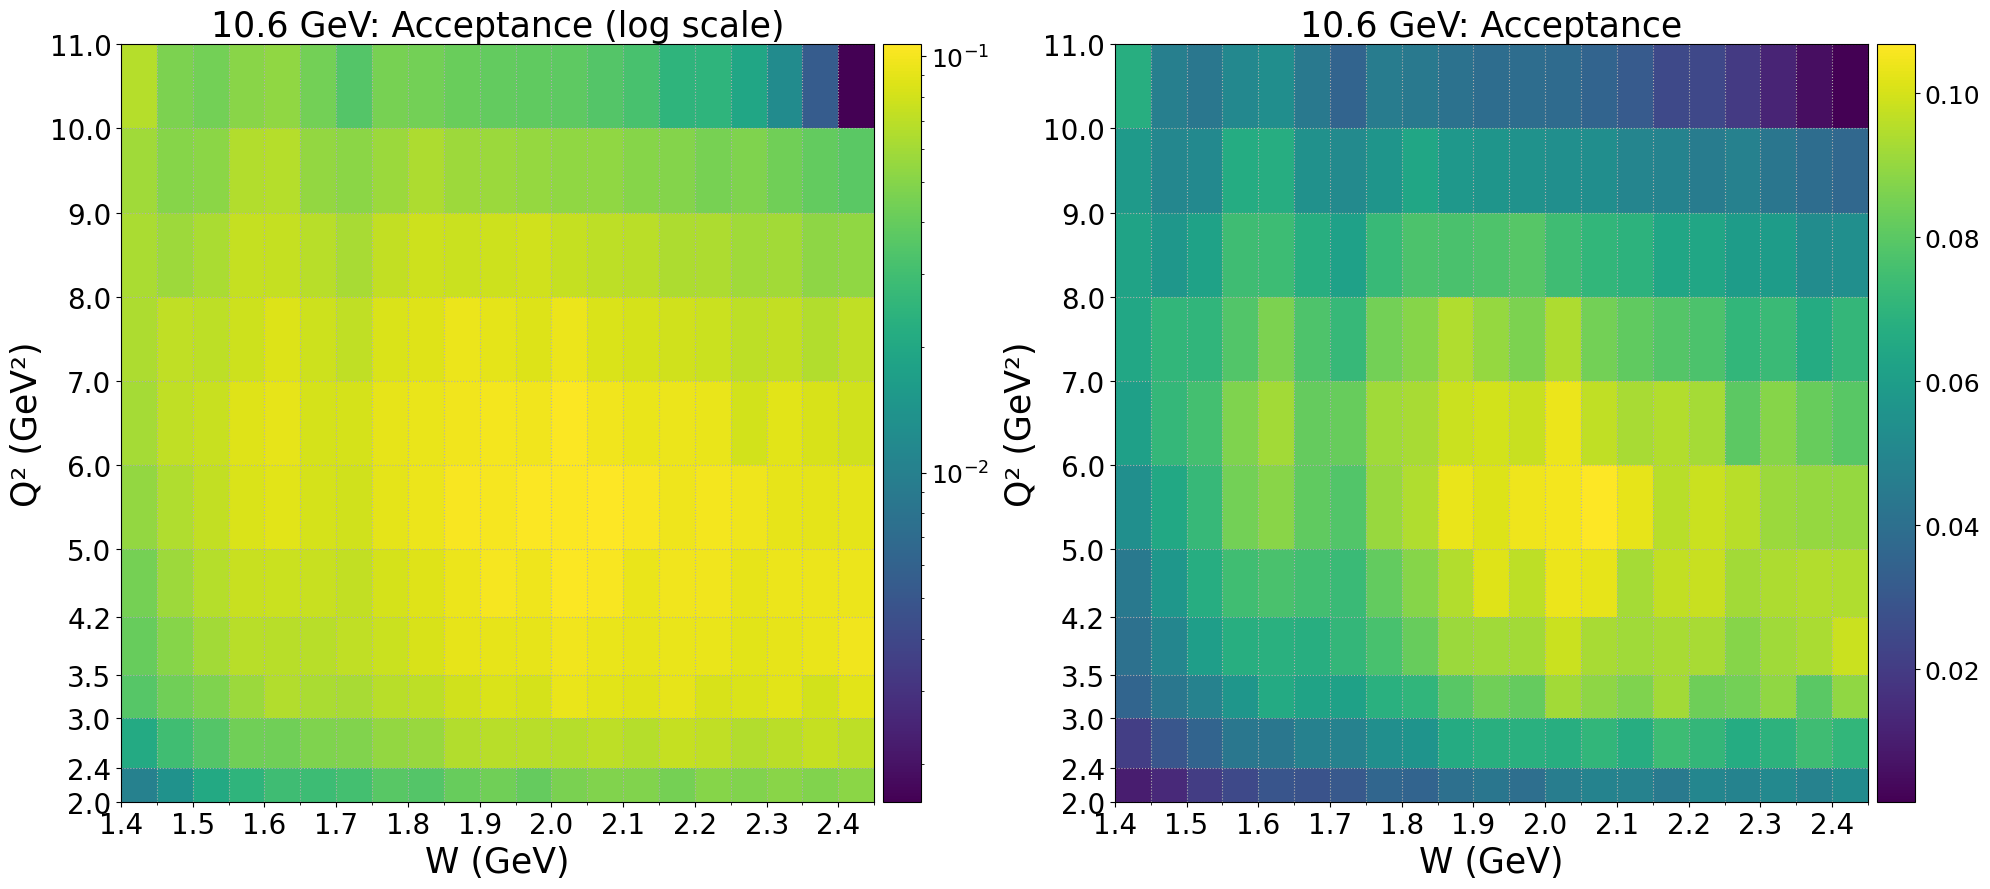

In [72]:
# Plot Acceptance: 10.6 GeV
def plot_acceptance(ax, data, log_norm=False, title=""):
    hist = ax.hist2d(
        data.w_val.to_numpy(),
        data.q2_val.to_numpy(),
        bins=[bin_x, bin_y],
        cmap='viridis', #inferno
        density=False,
        cmin=0,
        norm=mpl.colors.LogNorm() if log_norm else None,
        weights=data.acceptance,
    )

    # Labels / format
    ax.set_title(title, fontsize=25)
    ax.set_xlabel("W (GeV)", fontsize=25)
    ax.set_ylabel("Q² (GeV²)", fontsize=25)
    ax.tick_params(axis='both', which='both', labelsize=20)

    # grid
    ax.set_xticks(np.arange(1.4, 2.45, 0.1))
    ax.set_xticks(bin_x, minor=True)
    ax.set_yticks(bin_y)
    ax.grid(which='both', linestyle=':')

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.09)
    cbar = plt.colorbar(hist[3], cax=cax)
    cbar.ax.tick_params(labelsize=18)  # <--- adjust numeric labels

# def plot_acceptance(ax, data, log_norm=False, title=""):
#     # Create histogram
#     hist = ax.hist2d(
#         # data["w"], data["q2"],
#         # bins=60,
#         data.w_val.to_numpy(),
#         data.q2_val.to_numpy(),
#         bins=[bin_x, bin_y],
#         cmap='inferno',
#         # range=[[data["w"].min(), data["w"].max()],
#         #        [data["q2"].min(), data["q2"].max()]],
#         norm=mpl.colors.LogNorm() if log_norm else None
#     )

#     ax.set_title(title, fontsize=22)
#     ax.set_xlabel("W (GeV)", fontsize=20)
#     ax.set_ylabel("Q² (GeV²)", fontsize=20)

#     # Extract histogram values (hist[0] is the 2D array)
#     H = hist[0]

#     # --- Prevent colorbar crash ---
#     if np.all(H <= 0) or np.all(~np.isfinite(H)):
#         ax.text(0.5, 0.5, "No data in this bin",
#                 ha='center', va='center', fontsize=18, transform=ax.transAxes)
#         return  # <-- DON'T create a colorbar

#     # Only add colorbar when valid
#     divider = make_axes_locatable(ax)
#     cax = divider.append_axes("right", size="5%", pad=0.09)
#     cbar = plt.colorbar(hist[3], cax=cax)
#     cbar.ax.tick_params(labelsize=18)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_acceptance(axes[0], hist_10_6_gev_sim, log_norm=True, title="10.6 GeV: Acceptance (log scale)")
plot_acceptance(axes[1], hist_10_6_gev_sim, log_norm=False, title="10.6 GeV: Acceptance")

plt.tight_layout()
plt.show()


## integrated cross section

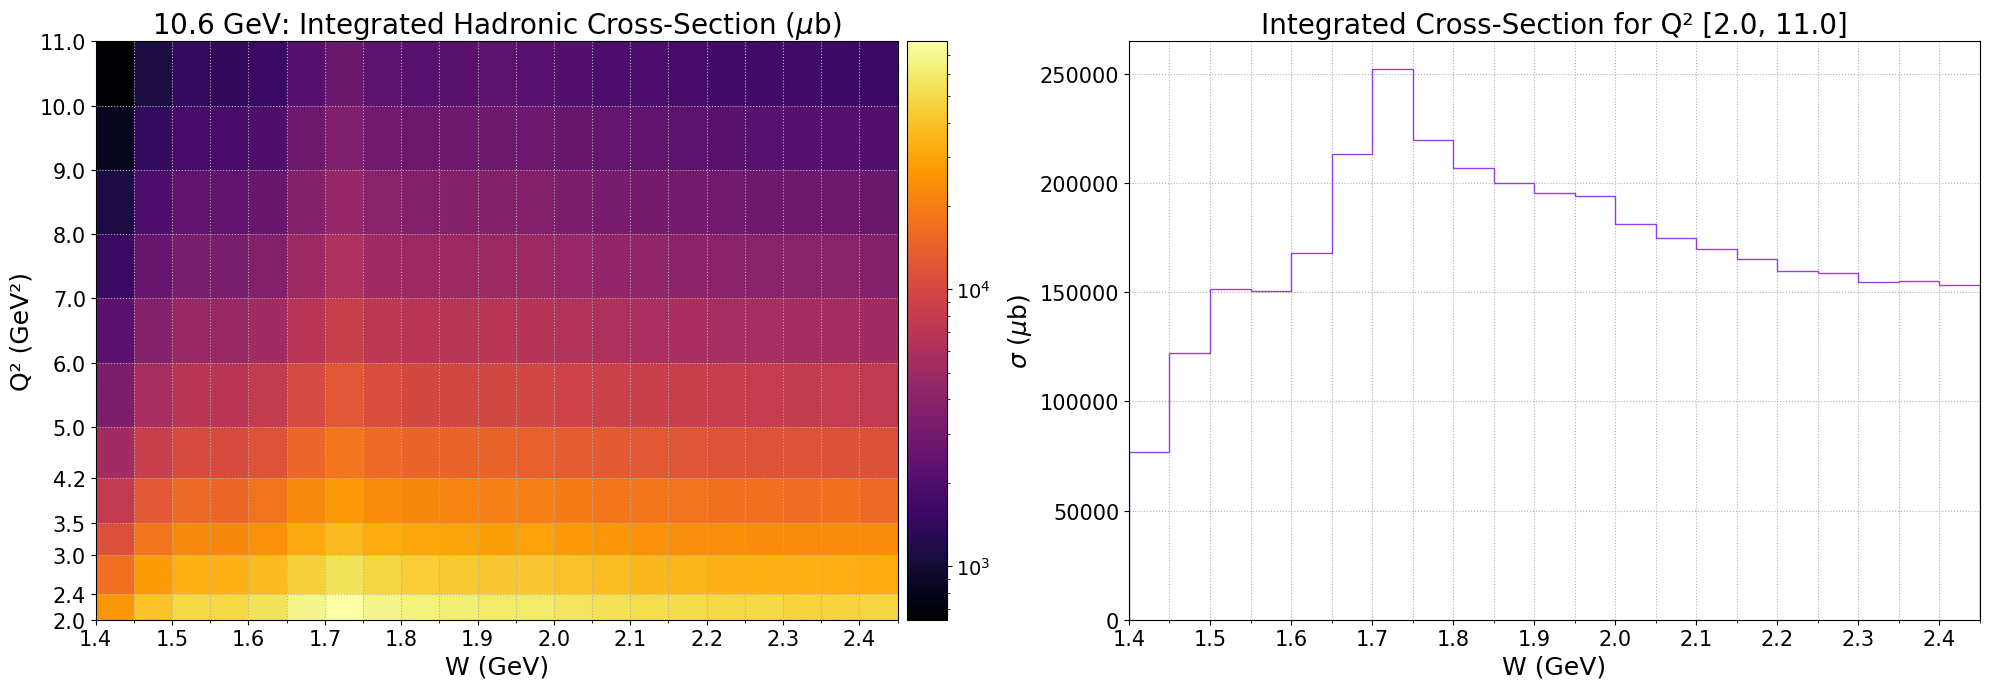

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ----------- LEFT: 2D integrated cross section
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_sim.w_val.to_numpy(), hist_10_6_gev_sim.q2_val.to_numpy(), 
                 bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_sim.cs_scaled)

ax.set_title('10.6 GeV: Integrated Hadronic Cross-Section ($\mu$b)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('Q² (GeV²)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)

# ----------- RIGHT: W-projected cross section
ax = axes[1]
ax.hist(hist_10_6_gev_sim.w_val.to_numpy(), range=(1.4, 2.5), bins=bin_x, weights=hist_10_6_gev_sim.cs_scaled, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('Integrated Cross-Section for Q² [2.0, 11.0]', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('$\sigma$ ($\mu$b)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


In [74]:
histogram_folder = Path(hist_base_path) / 'cross_sections'
histogram_folder.mkdir(parents=True, exist_ok=True)  # make folder if it doesn't exist

major_xticks = np.arange(1.4, 2.451, 0.1)

# Loop over Q² bins
for i in range(len(bin_y)-1):
    q2_min = bin_y[i]
    q2_max = bin_y[i+1]

    # Mask data for this Q² bin
    if i == len(bin_y)-2:  # include right edge for last bin
        mask = (hist_10_6_gev_sim.q2_val >= q2_min) & (hist_10_6_gev_sim.q2_val <= q2_max)
    else:
        mask = (hist_10_6_gev_sim.q2_val >= q2_min) & (hist_10_6_gev_sim.q2_val < q2_max)

    w_vals = hist_10_6_gev_sim.w_val[mask]
    cs_vals = hist_10_6_gev_sim.cs_scaled[mask]

    # Skip empty bins
    if len(w_vals) == 0:
        continue

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))  # more square-like

    # 1D histogram
    ax.hist(w_vals, bins=bin_x, weights=cs_vals, histtype='step', color='blueviolet', alpha=0.9)

    ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

    # Labels
    ax.set_title(f'Integrated Cross Section for Q² [{q2_min:.2f}, {q2_max:.2f}] GeV²', fontsize=20)
    ax.set_xlabel('W (GeV)', fontsize=18)
    ax.set_ylabel('$\sigma$ (μb)', fontsize=18)

    # Ticks and grid
    ax.set_xticks(major_xticks)
    ax.set_xticks(bin_x, minor=True)
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=15)


    # Save PNG
    filename = f'cs_Q2_{q2_min:.2f}_{q2_max:.2f}.png'
    plt.tight_layout()
    plt.savefig(histogram_folder / filename, dpi=300)
    plt.close(fig)


## luminosity

In [75]:
print("bin_x max =", bin_x[-1])
print("major_xticks max =", max(major_xticks))


bin_x max = 2.450000000000001
major_xticks max = 2.400000000000001


/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_1492/3163804940.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


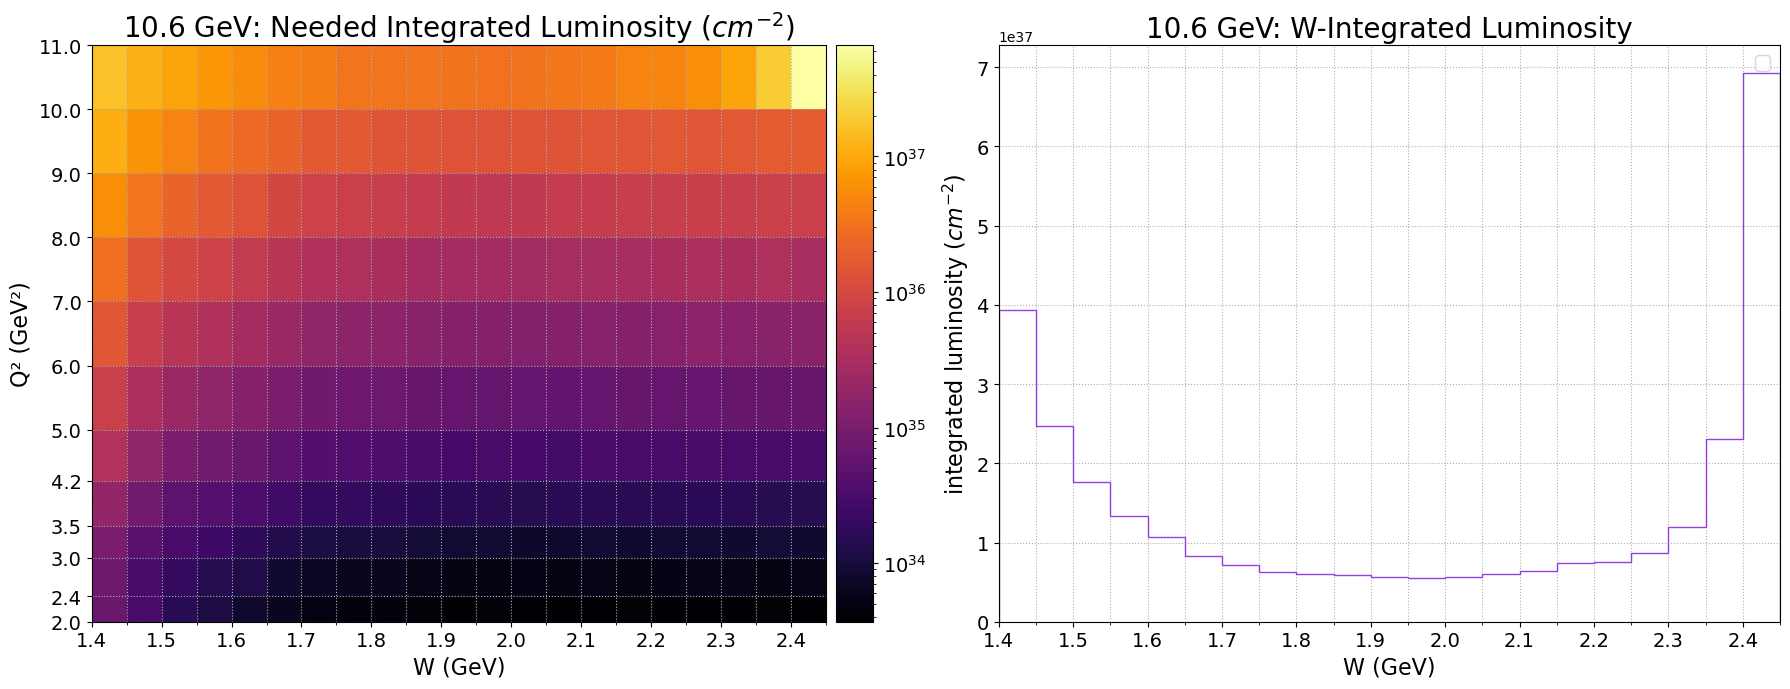

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # left and right panels

# ----------- LEFT: 2D luminosity
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_sim.w_val.to_numpy(), hist_10_6_gev_sim.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_sim.lumi_elec)

ax.set_title('10.6 GeV: Needed Integrated Luminosity ($cm^{-2}$)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Integrated Luminosity ($cm^{-2}$)', fontsize=16)

# ----------- RIGHT: 1D luminosity (projection on W)
ax = axes[1]
ax.hist(hist_10_6_gev_sim.w_val.to_numpy(), bins=bin_x, weights=hist_10_6_gev_sim.lumi_elec, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('10.6 GeV: W-Integrated Luminosity', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('integrated luminosity ($cm^{-2}$)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
# ax.grid(which='major', linestyle='-', linewidth=1)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


## charge

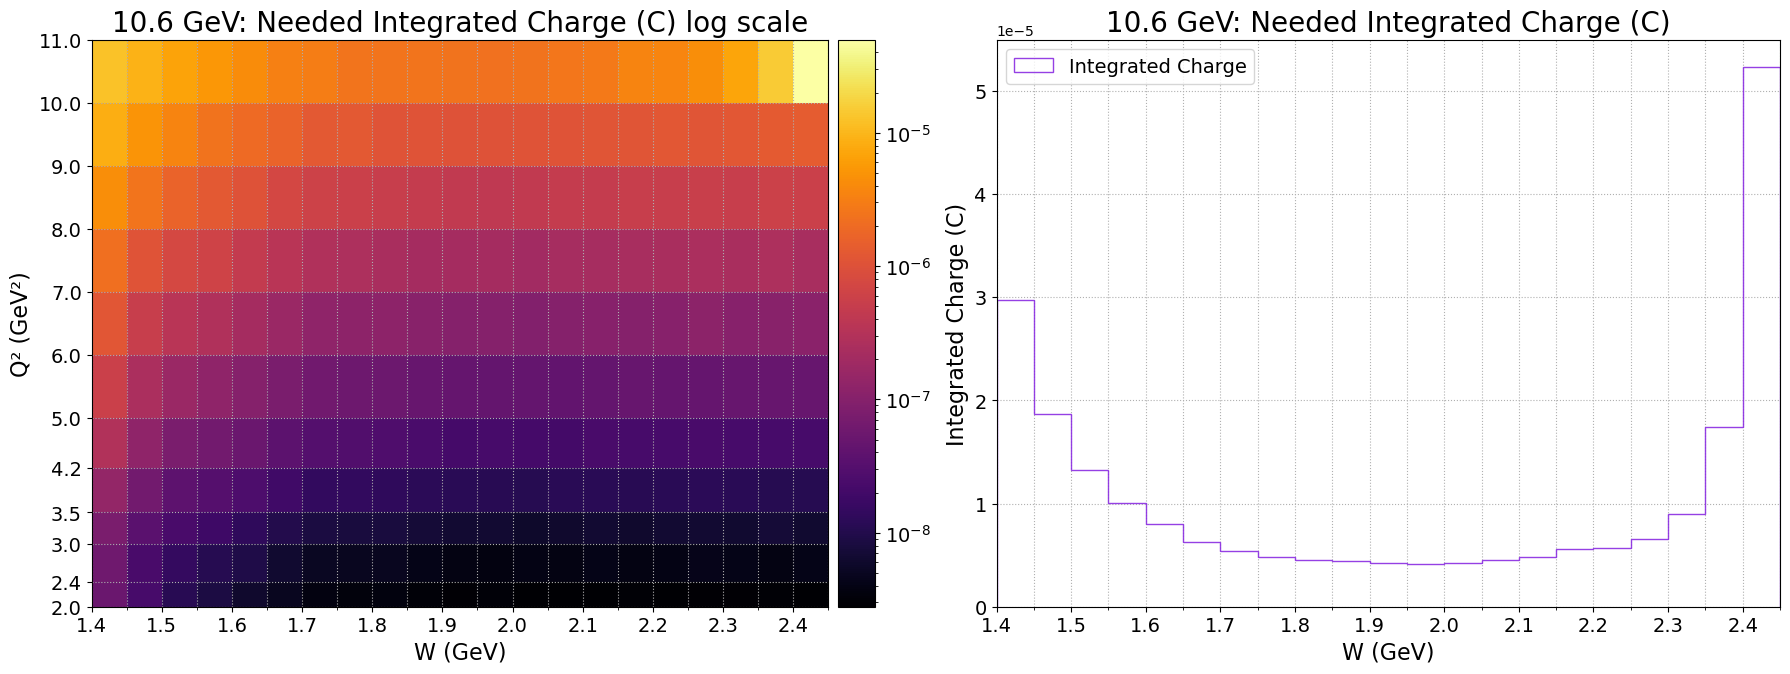

In [77]:
# Figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ----------- LEFT: log scale
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_sim.w_val.to_numpy(), hist_10_6_gev_sim.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_sim.q_elec)

ax.set_title('10.6 GeV: Needed Integrated Charge (C) log scale', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Integrated Charge (C)', fontsize=14)

# ----------- RIGHT: linear scale
ax = axes[1]
# 1D histogram of integrated charge vs W
ax.hist(
    hist_10_6_gev_sim.w_val.to_numpy(),
    bins=bin_x,
    range=(1.4, 2.5),
    weights=hist_10_6_gev_sim.q_elec,
    histtype='step',
    alpha=0.9,
    color='blueviolet',
    label='Integrated Charge'
)

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

# Labels
ax.set_title('10.6 GeV: Needed Integrated Charge (C)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Integrated Charge (C)', fontsize=16)

# Ticks
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# Grid
ax.grid(which='both', linestyle=':')

# Legend
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()



## time

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_1492/2165543000.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


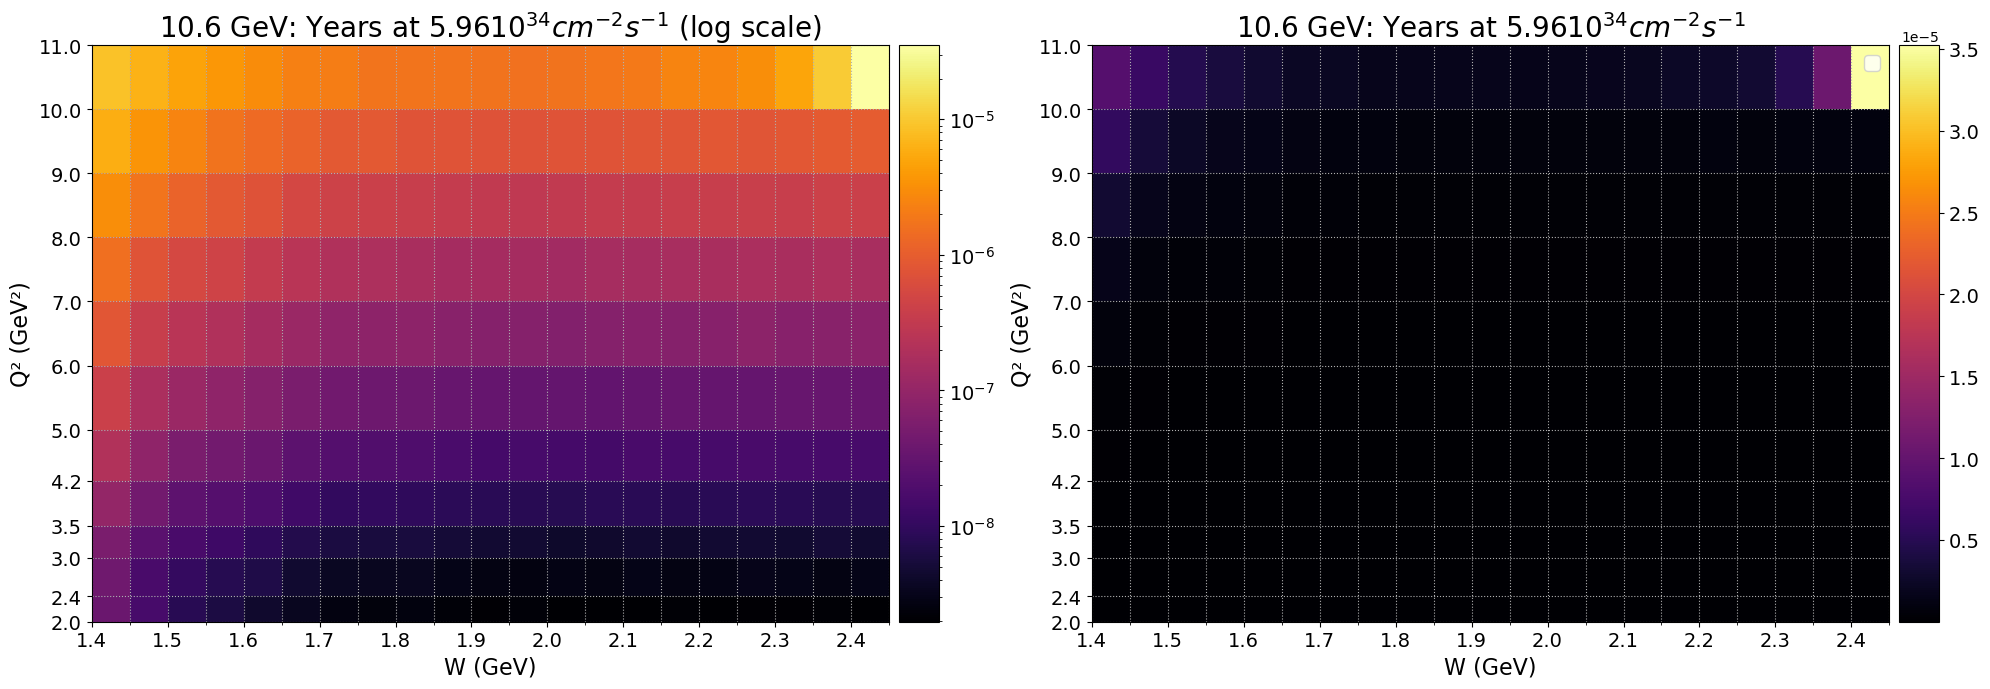

In [78]:
# Figure
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ---------------- LEFT: 2D log scale ----------------
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_sim.w_val.to_numpy(), hist_10_6_gev_sim.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_sim.no_year_45nA)

# Labels
ax.set_title('10.6 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$ (log scale)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)

# Ticks & Grid
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Years', fontsize=14)

# ---------------- RIGHT: 1D linear scale ----------------
# ax = axes[1]
# ax.hist(
#     hist_10_6_gev_sim.w_val.to_numpy(),
#     bins=bin_x,
#     range=(1.4, 2.5),
#     weights=hist_10_6_gev_sim.no_year_45nA,
#     histtype='step',
#     color='blueviolet',
#     alpha=0.9,
#     label='W-integrated Years'
# )

# # Labels
# ax.set_title('10.6 GeV: W-Integrated Years (linear scale)', fontsize=20)
# ax.set_xlabel('W (GeV)', fontsize=16)
# ax.set_ylabel('Years', fontsize=16)

# # Ticks & Grid
# ax.set_xticks(major_xticks)
# ax.set_xticks(bin_x, minor=True)
# ax.tick_params(axis='both', which='major', labelsize=14)
# ax.grid(which='both', linestyle=':')

ax = axes[1]
hist = ax.hist2d(hist_10_6_gev_sim.w_val.to_numpy(), hist_10_6_gev_sim.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, weights=hist_10_6_gev_sim.no_year_45nA)

# Labels
ax.set_title('10.6 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)

# Ticks & Grid
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Years', fontsize=14)

# Legend
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


# for exp data

In [27]:
## change all gen stuff to exp

exp_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)
exp_10_6GeV = exp_10_6GeV[(exp_10_6GeV.weight>0.0)]

hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/experiment/EXCL_topology')

In [28]:
# checking that my files read in correctly
exp_10_6GeV.head(14)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,40,2.202311,2.430970,1.009934e-25,0.631194,0.664800,1.881174,0.086615,0.850073,0.503881,...,0.569088,13.30103,45.80280,18.28310,35.15108,20.60836,20.84315,40.371930,25.138790,6.111936
1,344,2.203305,2.846577,1.009934e-25,0.517184,0.327475,2.586841,0.041096,0.851324,0.819614,...,0.197479,35.88552,34.66177,46.77804,50.57394,12.86621,12.67286,13.400130,30.980680,3.854774
2,350,2.032213,2.558562,1.009934e-25,-0.053706,0.235345,1.021956,-0.028165,1.165814,1.011257,...,0.207310,38.67536,34.94461,25.51579,28.09899,15.34483,11.81569,7.295735,7.350912,10.203760
3,397,2.239066,2.482506,1.009934e-25,-0.033012,0.080837,1.530876,-0.024375,2.523404,1.844889,...,0.684730,22.38681,22.08538,15.67668,14.78984,27.06520,30.31032,2.444446,10.981150,3.768268
4,447,1.806911,4.581568,1.009934e-25,0.044784,0.027203,0.918305,-0.000805,1.018532,0.947737,...,0.087077,42.97254,44.97281,20.11096,20.03687,17.11911,16.54055,2.957025,1.087643,0.871852
5,478,2.394952,3.628179,1.009934e-25,-0.035064,0.076767,0.923502,-0.004304,2.390393,2.299412,...,0.103000,14.91196,14.58772,27.20791,29.00056,15.70925,14.06219,1.180081,2.454786,2.863767
6,558,2.068573,2.589566,1.009934e-25,0.020585,-0.191051,1.128417,-0.035979,0.991425,0.759309,...,0.297911,34.14650,43.67003,12.37369,11.73264,28.14165,38.58739,12.355860,2.870714,12.101170
7,668,2.095608,2.239451,1.009934e-25,0.156183,0.431004,1.996879,-0.058252,0.620725,0.419948,...,0.379854,67.91714,61.81847,32.78282,25.02011,15.30371,10.51327,36.816540,21.324170,9.814139
8,820,1.735701,3.655120,1.009934e-25,0.142337,0.130232,1.053143,-0.009045,1.387835,1.256944,...,0.197885,26.09541,32.37085,30.98298,44.26196,18.28695,22.49949,6.441572,13.472410,4.266520
9,841,2.254004,4.714986,1.009934e-25,-0.064110,-0.032876,0.814008,-0.000744,2.469707,2.463234,...,0.029233,19.33495,19.80252,22.60106,21.88687,31.17138,31.65157,0.662219,1.434259,0.778210


In [29]:
exp_10_6GeV["weight"] = 1.0
exp_10_6GeV.head(6)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,40,2.202311,2.430970,1.0,0.631194,0.664800,1.881174,0.086615,0.850073,0.503881,...,0.569088,13.30103,45.80280,18.28310,35.15108,20.60836,20.84315,40.371930,25.138790,6.111936
1,344,2.203305,2.846577,1.0,0.517184,0.327475,2.586841,0.041096,0.851324,0.819614,...,0.197479,35.88552,34.66177,46.77804,50.57394,12.86621,12.67286,13.400130,30.980680,3.854774
2,350,2.032213,2.558562,1.0,-0.053706,0.235345,1.021956,-0.028165,1.165814,1.011257,...,0.207310,38.67536,34.94461,25.51579,28.09899,15.34483,11.81569,7.295735,7.350912,10.203760
3,397,2.239066,2.482506,1.0,-0.033012,0.080837,1.530876,-0.024375,2.523404,1.844889,...,0.684730,22.38681,22.08538,15.67668,14.78984,27.06520,30.31032,2.444446,10.981150,3.768268
4,447,1.806911,4.581568,1.0,0.044784,0.027203,0.918305,-0.000805,1.018532,0.947737,...,0.087077,42.97254,44.97281,20.11096,20.03687,17.11911,16.54055,2.957025,1.087643,0.871852
5,478,2.394952,3.628179,1.0,-0.035064,0.076767,0.923502,-0.004304,2.390393,2.299412,...,0.103000,14.91196,14.58772,27.20791,29.00056,15.70925,14.06219,1.180081,2.454786,2.863767


In [78]:
# remove event colummn now
exp_10_6GeV.drop(columns=['event'], inplace=True, errors='ignore')


## define w-q2 bins

In [79]:
# w-q2 ranges
bin_x = np.arange(1.4, 2.45, 0.05)
bin_y = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,12.0]

major_xticks = np.round(np.arange(1.4, 2.45 + 1e-6, 0.1), 2)

In [1012]:
# find number of exp events in each w-q2 bin from 10.6 GeV simulations (w and q2 are my x and y values)
def calcFunc(df):
    exp=df

    with open('output_10_6_exp.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val','q2_val','exp_events' ,'flux','weight','cross_section','formfactor','cs_scaled'])
        NSIGMA = 4
        cut_data = {}
    
        # Make w bins
        w_bin_ranges = bin_x
        
        # Cuts the exp w data into the ranges from above
        exp['w_bin'] = pd.cut(exp.w, w_bin_ranges)
        # unique_w = exp.w_bin.unique()
        # unique_w = pd.Index.sort_values(unique_w)
        # unique_w = unique_w.dropna()
        unique_w = exp['w_bin'].cat.categories

        # Make q2 bins
        q2_bin_ranges = bin_y
        
        # Cuts the exp q2 data into the ranges from above
        exp['q2_bin'] = pd.cut(exp.q2, q2_bin_ranges)
        # unique_q2 = exp.q2_bin.unique()
        # unique_q2 = pd.Index.sort_values(unique_q2)
        # unique_q2 = unique_q2.dropna()
        unique_q2 = exp['q2_bin'].cat.categories

        
        # function to calculate virtual photon flux
        def flux(w,q2_value):
            E_beam = 10.6
            MASS_P = 0.938;
            PI = 3.14159265358979323846;

            omega = (w * w + q2_value - MASS_P * MASS_P) / (2. * MASS_P);

            en_elp = E_beam - omega;
            th_elp = 2 * math.asin(math.sqrt(q2_value / 4. / E_beam / en_elp));

            epsilon = 1 / (1. + 2. * (1. + omega * omega / q2_value) * (math.tan(th_elp / 2.)) * (math.tan(th_elp / 2.)));

            flux_calc = (omega - q2_value / 2. / MASS_P) / 137.;

            flux_calc = flux_calc / 2. / (PI) / E_beam / q2_value / (1 - epsilon);
            flux_calc = flux_calc * w / E_beam / MASS_P;

            return flux_calc;
             
        # go through each w-q2 bin
        for w in unique_w:
            for q2 in unique_q2:
                data = exp[(exp.w_bin == w) & (exp.q2_bin == q2)]
                w_val = (w.right+w.left)/2.0
                q2_val = (q2.right+q2.left)/2.0
                virtual_flux = flux(w_val,q2_val)
                ff_scale=(1/(1+(q2_val/0.7))**( 0.31660)) / ((1/(1+0.65/0.7))**(1.18085))
                index = data.index
                number_of_rows = len(index) 
                weight_sum=data['weight'].sum() # / 1e4  # divide weight by 10^4 for new weights by krishna ***this is done at the csv file creation level, not in the notebook
                cs = weight_sum/(number_of_rows*virtual_flux)
                cs_scaled = cs* ff_scale
                
                out_binned_exclusive_writer.writerow([w_val, q2_val, number_of_rows, 
                                                          "{:.5f}".format(virtual_flux), 
                                                          "{:.5f}".format(weight_sum), 
                                                          "{:.5f}".format(cs), 
                                                          "{:.5f}".format(ff_scale), 
                                                          "{:.5f}".format(cs_scaled)])
                    
                print(w_val, ",", q2_val, ",", "{:.7f}".format(virtual_flux), ",", number_of_rows, ",", 
                      "{:.5f}".format(weight_sum), ",", "{:.5f}".format(cs), ",", "{:.5f}".format(ff_scale), ",", "{:.5f}".format(cs_scaled))

    return cut_data

In [1013]:
# calculations for 10.6 GeV generated events
my_output = calcFunc(exp_10_6GeV)

1.4249999999999998 , 2.2 , 0.0001553 , 2154 , 2154.00000 , 6438.89808 , 1.38479 , 8916.51191
1.4249999999999998 , 2.7 , 0.0000964 , 2992 , 2992.00000 , 10372.77403 , 1.31678 , 13658.63631
1.4249999999999998 , 3.25 , 0.0000617 , 1682 , 1682.00000 , 16211.68768 , 1.25573 , 20357.49034
1.4249999999999998 , 3.85 , 0.0000405 , 1407 , 1407.00000 , 24699.29535 , 1.20075 , 29657.65472
1.4249999999999998 , 4.6 , 0.0000257 , 915 , 915.00000 , 38980.44336 , 1.14412 , 44598.44161
1.4249999999999998 , 5.5 , 0.0000160 , 465 , 465.00000 , 62553.78986 , 1.08870 , 68102.18834
1.4249999999999998 , 6.5 , 0.0000101 , 207 , 207.00000 , 98677.22884 , 1.03836 , 102462.30599
1.4249999999999998 , 7.5 , 0.0000068 , 99 , 99.00000 , 147326.10611 , 0.99647 , 146806.36796
1.4249999999999998 , 8.5 , 0.0000047 , 37 , 37.00000 , 210726.20798 , 0.96082 , 202470.60259
1.4249999999999998 , 9.5 , 0.0000034 , 15 , 15.00000 , 291118.13478 , 0.92994 , 270722.96328
1.4249999999999998 , 10.5 , 0.0000026 , 14 , 14.00000 , 39066

In [1014]:
hist_10_6_gev_exp=pd.read_csv('output_10_6_exp.csv',index_col=False)

In [1015]:
# display the first few rows to verify the results
print(hist_10_6_gev_exp.head(10))

   w_val  q2_val  exp_events     flux  weight  cross_section  formfactor  \
0  1.425    2.20        2154  0.00016  2154.0     6438.89808     1.38479   
1  1.425    2.70        2992  0.00010  2992.0    10372.77403     1.31678   
2  1.425    3.25        1682  0.00006  1682.0    16211.68768     1.25573   
3  1.425    3.85        1407  0.00004  1407.0    24699.29535     1.20075   
4  1.425    4.60         915  0.00003   915.0    38980.44336     1.14412   
5  1.425    5.50         465  0.00002   465.0    62553.78986     1.08870   
6  1.425    6.50         207  0.00001   207.0    98677.22884     1.03836   
7  1.425    7.50          99  0.00001    99.0   147326.10611     0.99647   
8  1.425    8.50          37  0.00000    37.0   210726.20798     0.96082   
9  1.425    9.50          15  0.00000    15.0   291118.13478     0.92994   

      cs_scaled  
0    8916.51191  
1   13658.63631  
2   20357.49034  
3   29657.65472  
4   44598.44161  
5   68102.18834  
6  102462.30599  
7  146806.36796  
8

## integrated cross section

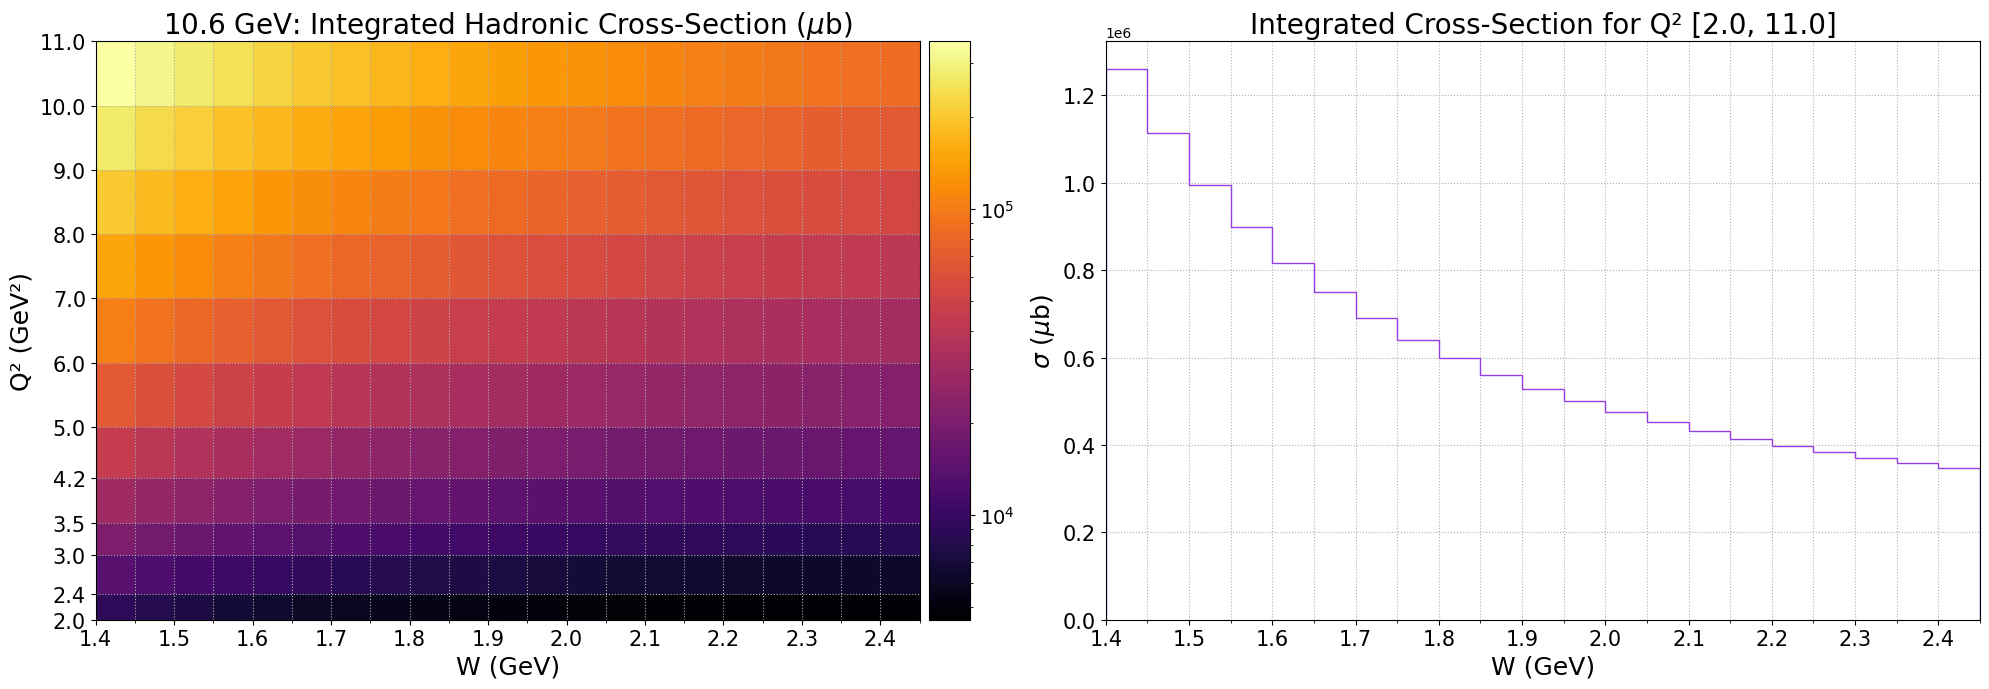

In [1016]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ----------- LEFT: 2D integrated cross section
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_exp.w_val.to_numpy(), hist_10_6_gev_exp.q2_val.to_numpy(), 
                 bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_exp.cs_scaled)

ax.set_title('10.6 GeV: Integrated Hadronic Cross-Section ($\mu$b)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('Q² (GeV²)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)

# ----------- RIGHT: W-projected cross section
ax = axes[1]
ax.hist(hist_10_6_gev_exp.w_val.to_numpy(), range=(1.4, 2.5), bins=bin_x, weights=hist_10_6_gev_exp.cs_scaled, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('Integrated Cross-Section for Q² [2.0, 11.0]', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('$\sigma$ ($\mu$b)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


In [1017]:
histogram_folder = Path(hist_base_path) / 'cross_sections'
histogram_folder.mkdir(parents=True, exist_ok=True)  # make folder if it doesn't exist

major_xticks = np.arange(1.4, 2.51, 0.1)

# Loop over Q² bins
for i in range(len(bin_y)-1):
    q2_min = bin_y[i]
    q2_max = bin_y[i+1]

    # Mask data for this Q² bin
    if i == len(bin_y)-2:  # include right edge for last bin
        mask = (hist_10_6_gev_exp.q2_val >= q2_min) & (hist_10_6_gev_exp.q2_val <= q2_max)
    else:
        mask = (hist_10_6_gev_exp.q2_val >= q2_min) & (hist_10_6_gev_exp.q2_val < q2_max)

    w_vals = hist_10_6_gev_exp.w_val[mask]
    cs_vals = hist_10_6_gev_exp.cs_scaled[mask]

    # Skip empty bins
    if len(w_vals) == 0:
        continue

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))  # more square-like

    # 1D histogram
    ax.hist(w_vals, bins=bin_x, weights=cs_vals, histtype='step', color='blueviolet', alpha=0.9)

    ax.set_xlim(bin_x[0], bin_x[-1])  # Force axis to match bin range

    # Labels
    ax.set_title(f'Integrated Cross Section for Q² [{q2_min:.2f}, {q2_max:.2f}] GeV²', fontsize=20)
    ax.set_xlabel('W (GeV)', fontsize=16)
    ax.set_ylabel('$\sigma$ (μb)', fontsize=16)

    # Ticks and grid
    ax.set_xticks(major_xticks)
    ax.set_xticks(bin_x, minor=True)
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Save PNG
    filename = f'cs_Q2_{q2_min:.2f}_{q2_max:.2f}.png'
    plt.tight_layout()
    plt.savefig(histogram_folder / filename, dpi=300)
    plt.close(fig)
